# Exploratory analysis on the insurance dataset. Produces the charts used in
the README and mirrors the KPIs later rebuilt as a Power BI report.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
OUT = "../screenshots"

In [5]:
customers = pd.read_csv("../data/raw/customers.csv", parse_dates=["customer_since"])

In [6]:
policies = pd.read_csv("../data/raw/policies.csv", parse_dates=["start_date"])

In [7]:
claims = pd.read_csv("../data/raw/claims.csv", parse_dates=["claim_date"])

In [8]:
# Earned premium = annual premium x years of exposure in the observation
# window (2022-01-01 to 2025-12-31). Comparing total claims paid across a
# 4-year window against a single year of premium overstates loss ratio, so
# this mirrors how insurers actually compute "earned" premium for a KPI.

In [9]:
OBS_END = pd.Timestamp("2025-12-31")
policies["exposure_years"] = ((OBS_END - policies["start_date"]).dt.days / 365.25).clip(upper=4.0)
policies["earned_premium_eur"] = policies["annual_premium_eur"] * policies["exposure_years"]

In [10]:
policies["exposure_years"]

0       3.879535
1       2.992471
2       1.478439
3       2.318960
4       3.956194
          ...   
6995    3.164956
6996    1.347023
6997    3.605749
6998    1.845311
6999    0.665298
Name: exposure_years, Length: 7000, dtype: float64

In [11]:
# --- 1. Loss ratio by policy type ---------------------------------------
paid = claims[claims["claim_status"] == "Paid"]
premium_by_type = policies.groupby("policy_type")["earned_premium_eur"].sum()

In [12]:
claims_by_type = paid.merge(policies[["policy_id", "policy_type"]], on="policy_id")
claims_by_type = claims_by_type.groupby("policy_type")["claim_amount_eur"].sum()
loss_ratio = (claims_by_type / premium_by_type * 100).sort_values(ascending=False)

In [13]:
loss_ratio

policy_type
Wohngebaeude          100.202592
Haftpflicht            85.701718
Hausrat                70.945929
Kfz                    61.945610
Lebensversicherung     35.618608
dtype: float64

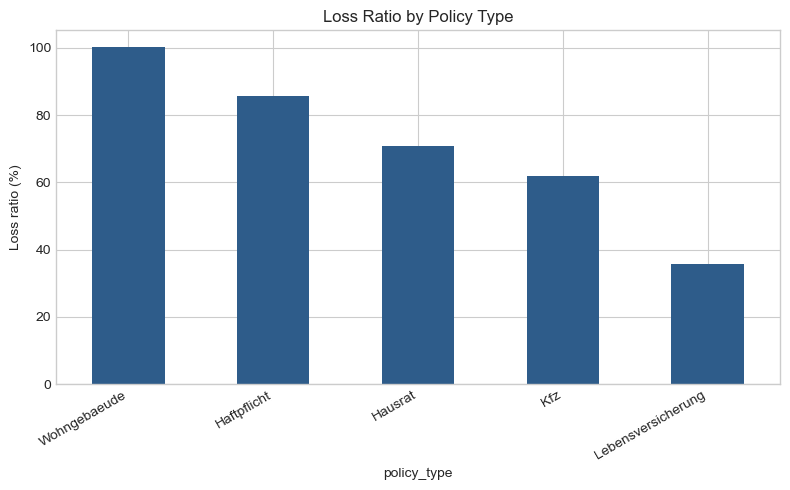

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
loss_ratio.plot(kind="bar", ax=ax, color="#2E5C8A")
ax.set_ylabel("Loss ratio (%)")
ax.set_title("Loss Ratio by Policy Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT}/loss_ratio_by_policy_type.png", dpi=150)

In [15]:
# --- 2. Claims volume over time ------------------------------------------
monthly_claims = claims.set_index("claim_date").resample("M")["claim_amount_eur"].sum()

In [16]:
claims.set_index("claim_date").resample("M")["claim_amount_eur"].sum()

claim_date
2022-02-28      4299.67
2022-03-31      2715.31
2022-04-30      4407.63
2022-05-31     15900.78
2022-06-30     17712.27
2022-07-31      4310.27
2022-08-31     25013.68
2022-09-30     10002.46
2022-10-31     21050.59
2022-11-30     40018.97
2022-12-31     75063.32
2023-01-31     74984.05
2023-02-28     11520.88
2023-03-31     61540.06
2023-04-30     50626.34
2023-05-31     63578.74
2023-06-30     72756.24
2023-07-31     66953.75
2023-08-31     46355.75
2023-09-30     75869.66
2023-10-31     96779.34
2023-11-30    105017.42
2023-12-31    103960.98
2024-01-31     96019.84
2024-02-29     59026.27
2024-03-31    196268.40
2024-04-30     77816.17
2024-05-31    152744.99
2024-06-30    210331.97
2024-07-31    119504.79
2024-08-31    145643.43
2024-09-30    213395.19
2024-10-31    206873.03
2024-11-30    174826.65
2024-12-31    258534.73
2025-01-31    323277.84
2025-02-28    203569.99
2025-03-31    227773.34
2025-04-30    328946.44
2025-05-31    335461.42
2025-06-30    351377.72
2025-

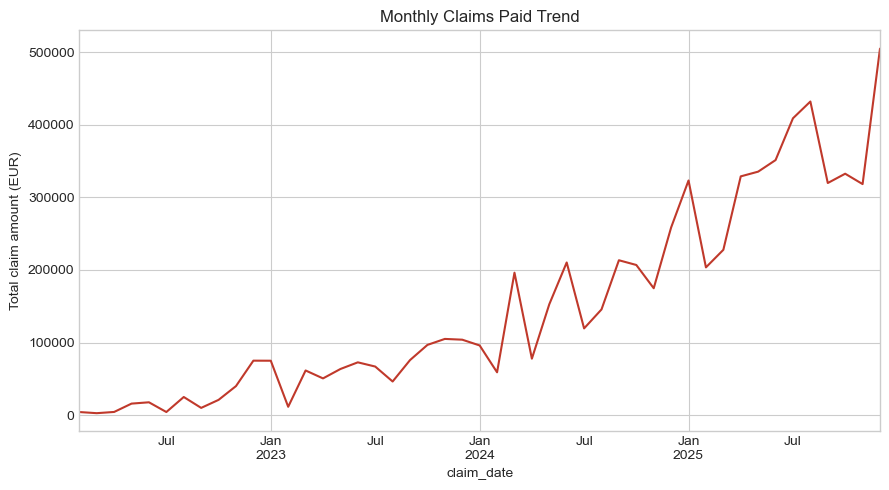

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
monthly_claims.plot(ax=ax, color="#C0392B")
ax.set_ylabel("Total claim amount (EUR)")
ax.set_title("Monthly Claims Paid Trend")
plt.tight_layout()
plt.savefig(f"{OUT}/monthly_claims_trend.png", dpi=150)

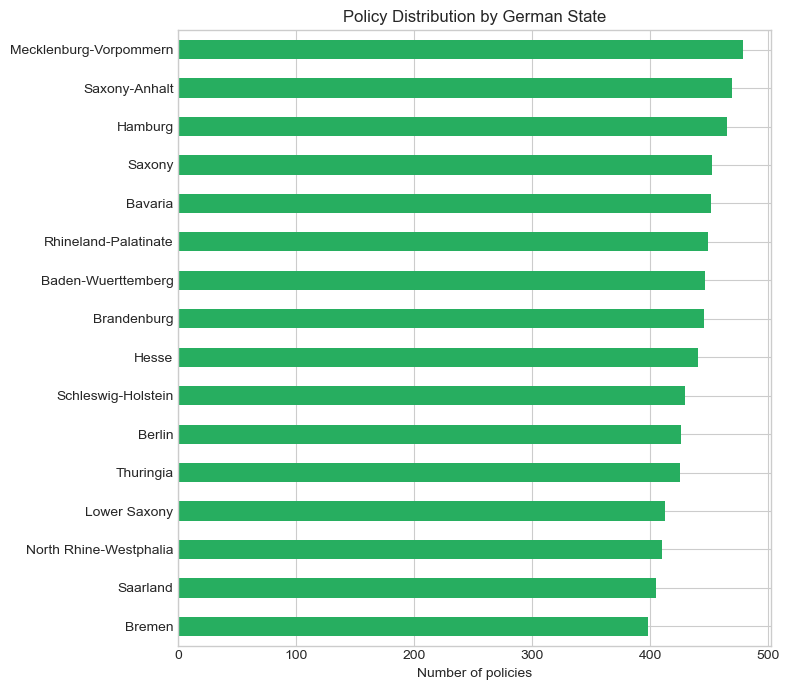

In [18]:
# --- 3. Policy distribution by region -------------------------------------
region_counts = policies["region"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 7))
region_counts.plot(kind="barh", ax=ax, color="#27AE60")
ax.set_xlabel("Number of policies")
ax.set_title("Policy Distribution by German State")
plt.tight_layout()
plt.savefig(f"{OUT}/policy_distribution_by_region.png", dpi=150)


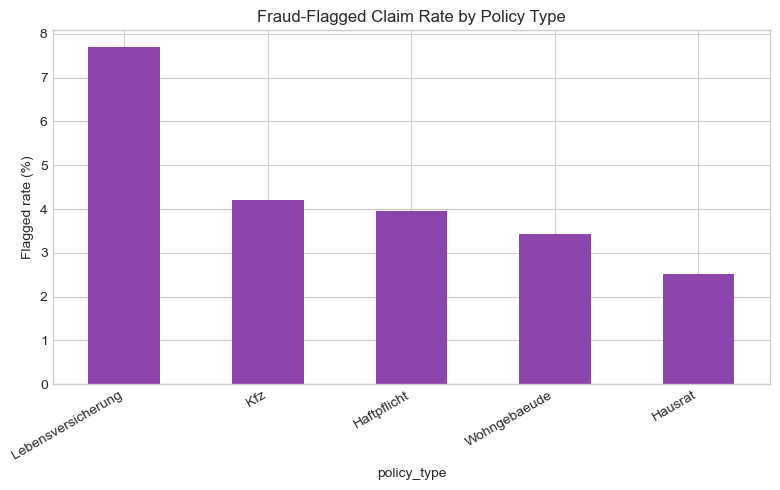

In [19]:
# --- 4. Fraud-flagged rate by policy type ---------------------------------
merged = claims.merge(policies[["policy_id", "policy_type"]], on="policy_id")
fraud_rate = merged.groupby("policy_type")["fraud_flag"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
fraud_rate.plot(kind="bar", ax=ax, color="#8E44AD")
ax.set_ylabel("Flagged rate (%)")
ax.set_title("Fraud-Flagged Claim Rate by Policy Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT}/fraud_flag_rate.png", dpi=150)


In [20]:
# --- Print summary KPIs for the README ------------------------------------
total_premium = policies["earned_premium_eur"].sum()
total_claims_paid = paid["claim_amount_eur"].sum()
overall_loss_ratio = total_claims_paid / total_premium * 100
churn_rate = (policies["status"].isin(["Lapsed", "Cancelled"])).mean() * 100

print(f"Total premium written:   EUR {total_premium:,.0f}")
print(f"Total claims paid:       EUR {total_claims_paid:,.0f}")
print(f"Overall loss ratio:      {overall_loss_ratio:.1f}%")
print(f"Overall churn rate:      {churn_rate:.1f}%")
print("Charts written to ../screenshots/")

Total premium written:   EUR 8,349,802
Total claims paid:       EUR 5,289,919
Overall loss ratio:      63.4%
Overall churn rate:      22.0%
Charts written to ../screenshots/
